In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (7, 5)

In [3]:
df = pd.read_csv("sample_data/train.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (595212, 59)


,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,...,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,...,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,...,4,2,7,7,0,1,1,0,1,0
3,16,0,0,1,2,0,0,1,0,0,...,2,2,4,9,0,0,0,0,0,0
4,17,0,0,2,0,1,0,1,0,0,...,3,1,1,3,0,0,0,1,1,0


In [4]:
binary_cols = [col for col in df.columns if "_bin" in col]
cat_cols    = [col for col in df.columns if "_cat" in col]

# continuous = all other columns except id and target
cont_cols   = [
    col for col in df.columns
    if col not in binary_cols + cat_cols + ["target", "id"]
]

print("Binary features:", len(binary_cols))
print("Categorical features:", len(cat_cols))
print("Continuous features:", len(cont_cols))

binary_cols[:5], cat_cols[:5], cont_cols[:5]

Binary features: 17
Categorical features: 14
Continuous features: 26


(['ps_ind_06_bin',
  'ps_ind_07_bin',
  'ps_ind_08_bin',
  'ps_ind_09_bin',
  'ps_ind_10_bin'],
 ['ps_ind_02_cat',
  'ps_ind_04_cat',
  'ps_ind_05_cat',
  'ps_car_01_cat',
  'ps_car_02_cat'],
 ['ps_ind_01', 'ps_ind_03', 'ps_ind_14', 'ps_ind_15', 'ps_reg_01'])

In [5]:
# Missing value analysis
# /missing values are coded as -1

y = df["target"]
X_raw = df.drop(["target", "id"], axis=1)

missing_rate = (X_raw == -1).sum() / len(X_raw)
missing_rate = missing_rate.sort_values(ascending=False)

print("Top missing features:")
missing_rate.head(10)

Top missing features:


,0
ps_car_03_cat,0.690898
ps_car_05_cat,0.447825
ps_reg_03,0.181065
ps_car_14,0.071605
ps_car_07_cat,0.019302
ps_ind_05_cat,0.009760
ps_car_09_cat,0.000956
ps_ind_02_cat,0.000363
ps_car_01_cat,0.000180
ps_ind_04_cat,0.000139


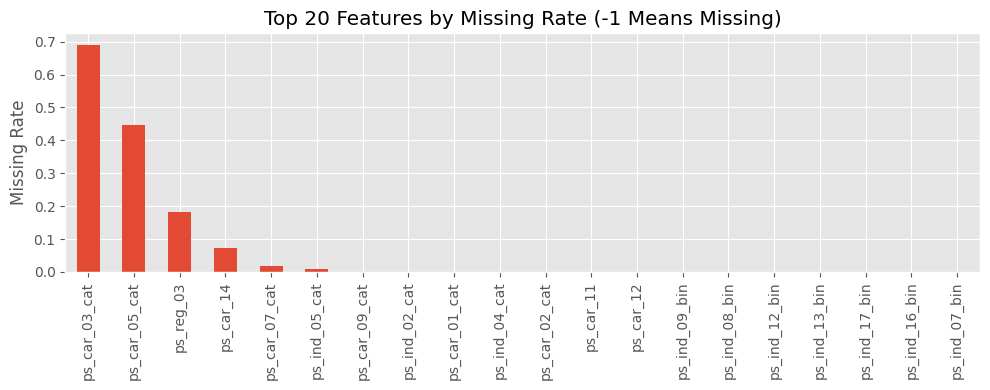

In [6]:
missing_rate.head(20).plot(kind="bar", figsize=(10,4))
plt.title("Top 20 Features by Missing Rate (-1 Means Missing)")
plt.ylabel("Missing Rate")
plt.tight_layout()
plt.show()

In [7]:
#
# cols_to_drop = ["ps_car_03_cat"]
# X = X.drop(columns=cols_to_drop)
# cat_cols = [c for c in cat_cols if c not in cols_to_drop]


We dropped ps_car_03_cat due to its extremely high missing rate (~69%), which can introduce noise and instability while providing limited predictive information.”

In [8]:
# Cleaning continuous columns: replace -1 with median

X = X_raw.copy()

# Replace -1 with NaN first
X[cont_cols] = X[cont_cols].replace(-1, np.nan)

# Fill NaN with median for each continuous feature
for col in cont_cols:
    median_val = X[col].median()
    X[col] = X[col].fillna(median_val)

print("Continuous features cleaned. Example values:")
X[cont_cols].head()

Continuous features cleaned. Example values:


,ps_ind_01,ps_ind_03,ps_ind_14,ps_ind_15,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_11,ps_car_12,ps_car_13,...,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14
0,2,5,0,11,0.7,0.2,0.718070,2.0,0.400000,0.883679,...,1,10,1,10,1,5,9,1,5,8
1,1,7,0,3,0.8,0.4,0.766078,3.0,0.316228,0.618817,...,1,9,5,8,1,7,3,1,1,9
2,5,9,0,12,0.0,0.0,0.801561,1.0,0.316228,0.641586,...,2,9,1,8,2,7,4,2,7,7
3,0,2,0,8,0.9,0.2,0.580948,1.0,0.374166,0.542949,...,4,7,1,8,4,2,2,2,4,9
4,0,0,0,9,0.7,0.6,0.840759,3.0,0.316070,0.565832,...,2,6,3,10,2,12,3,1,1,3


In [9]:
# Scale continuous features
scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X[cont_cols])

# Convert back to DataFrame
X_cont_scaled = pd.DataFrame(
    X_cont_scaled,
    columns=cont_cols,
    index=X.index
)

print("Scaled continuous features shape:", X_cont_scaled.shape)
X_cont_scaled.head()

Scaled continuous features shape: (595212, 26)


,ps_ind_01,ps_ind_03,ps_ind_14,ps_ind_15,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_11,ps_car_12,ps_car_13,...,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14
0,0.050218,0.213594,-0.097621,1.043440,0.309442,-0.591654,-0.506132,-0.415746,0.343963,0.313526,...,-0.780567,1.731646,-1.417981,0.530322,-1.073849,-1.182124,1.525425,-0.367359,1.255372,0.167831
1,-0.453868,0.954362,-0.097621,-1.212598,0.657096,-0.096928,-0.353536,0.785466,-1.092966,-0.865800,...,-0.780567,0.982196,1.409748,-0.839850,-1.073849,-0.493559,-1.046515,-0.367359,-1.104669,0.531911
2,1.562477,1.695130,-0.097621,1.325445,-2.124135,-1.086380,-0.240749,-1.616957,-1.092966,-0.764418,...,0.100547,0.982196,-1.417981,-0.839850,-0.271891,-0.493559,-0.617858,0.463923,2.435393,-0.196249
3,-0.957955,-0.897559,-0.097621,0.197425,1.004750,-0.591654,-0.941992,-1.616957,-0.099167,-1.203608,...,1.862777,-0.516705,-1.417981,-0.839850,1.332025,-2.214970,-1.475171,0.463923,0.665362,0.531911
4,-0.957955,-1.638327,-0.097621,0.479430,0.309442,0.397799,-0.116155,0.785466,-1.095679,-1.101721,...,0.100547,-1.266155,-0.004117,0.530322,-0.271891,1.227851,-1.046515,-0.367359,-1.104669,-1.652569


In [10]:
# clean binary features
X_bin = X_raw[binary_cols].copy()

#
bin_missing_rate = (X_bin == -1).sum() / len(X_bin)
print("Binary missing (coded as -1):")
print(bin_missing_rate.sort_values(ascending=False).head(10))

#
for col in binary_cols:
    if (X_bin[col] == -1).any():

        mode_val = X_bin.loc[X_bin[col] != -1, col].mode()[0]
        X_bin[col] = X_bin[col].replace(-1, mode_val)

print("Finished cleaning binary features. Example:")
X_bin.head()


Binary missing (coded as -1):
ps_ind_06_bin    0.0
ps_ind_07_bin    0.0
ps_ind_08_bin    0.0
ps_ind_09_bin    0.0
ps_ind_10_bin    0.0
ps_ind_11_bin    0.0
ps_ind_12_bin    0.0
ps_ind_13_bin    0.0
ps_ind_16_bin    0.0
ps_ind_17_bin    0.0
dtype: float64
Finished cleaning binary features. Example:


,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,0,1,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1
1,0,0,1,0,0,0,0,0,0,0,1,0,1,1,0,1,0
2,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,1,0
3,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0



Binary features are 0/1 variables.

Any value of -1 is treated as missing. Since there are only two valid values (0 and 1), we impute -1 with the mode (the most frequent value) of that column.

This preserves the semantics of 0/1 features and avoids feeding the artificial value -1 into the model.

In [11]:
# ---- drop extremely high-missing categorical columns ----


#
high_missing_cat = [c for c in cat_cols if missing_rate[c] > 0.5]
print("Categorical cols with >50% missing:", high_missing_cat)

cat_cols_clean = [c for c in cat_cols if c not in high_missing_cat]

#
X_cat = X_raw[cat_cols_clean].copy()

#
X_cat = X_cat.astype("int32")

# One-hot
X_cat_ohe = pd.get_dummies(
    X_cat,
    columns=cat_cols_clean,
    prefix=cat_cols_clean,
    dummy_na=False
)

print("Original categorical shape:", X_cat.shape)
print("One-hot encoded shape:", X_cat_ohe.shape)
X_cat_ohe.head()


Categorical cols with >50% missing: ['ps_car_03_cat']
Original categorical shape: (595212, 13)
One-hot encoded shape: (595212, 181)


,ps_ind_02_cat_-1,ps_ind_02_cat_1,ps_ind_02_cat_2,ps_ind_02_cat_3,ps_ind_02_cat_4,ps_ind_04_cat_-1,ps_ind_04_cat_0,ps_ind_04_cat_1,ps_ind_05_cat_-1,ps_ind_05_cat_0,...,ps_car_11_cat_95,ps_car_11_cat_96,ps_car_11_cat_97,ps_car_11_cat_98,ps_car_11_cat_99,ps_car_11_cat_100,ps_car_11_cat_101,ps_car_11_cat_102,ps_car_11_cat_103,ps_car_11_cat_104
0,False,False,True,False,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,True
4,False,False,True,False,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False




We drop categorical features with extremely high missing rates (e.g., ps_car_03_cat with ~70% missing). Such features usually add more noise than signal.

For the remaining _cat variables, we keep -1 as a separate category, representing “unknown/missing”.

We then apply one-hot encoding using pd.get_dummies, so each category becomes a 0/1 indicator. This avoids imposing a fake numeric order on categorical IDs.

In [12]:

X_cont_scaled = X_cont_scaled.loc[X_raw.index]
X_bin         = X_bin.loc[X_raw.index]
X_cat_ohe     = X_cat_ohe.loc[X_raw.index]

#
X_prepared = pd.concat(
    [X_cont_scaled, X_bin, X_cat_ohe],
    axis=1
)

print("Final prepared feature matrix shape:", X_prepared.shape)
X_prepared.head()


Final prepared feature matrix shape: (595212, 224)


,ps_ind_01,ps_ind_03,ps_ind_14,ps_ind_15,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_11,ps_car_12,ps_car_13,...,ps_car_11_cat_95,ps_car_11_cat_96,ps_car_11_cat_97,ps_car_11_cat_98,ps_car_11_cat_99,ps_car_11_cat_100,ps_car_11_cat_101,ps_car_11_cat_102,ps_car_11_cat_103,ps_car_11_cat_104
0,0.050218,0.213594,-0.097621,1.043440,0.309442,-0.591654,-0.506132,-0.415746,0.343963,0.313526,...,False,False,False,False,False,False,False,False,False,False
1,-0.453868,0.954362,-0.097621,-1.212598,0.657096,-0.096928,-0.353536,0.785466,-1.092966,-0.865800,...,False,False,False,False,False,False,False,False,False,False
2,1.562477,1.695130,-0.097621,1.325445,-2.124135,-1.086380,-0.240749,-1.616957,-1.092966,-0.764418,...,False,False,False,False,False,False,False,False,False,False
3,-0.957955,-0.897559,-0.097621,0.197425,1.004750,-0.591654,-0.941992,-1.616957,-0.099167,-1.203608,...,False,False,False,False,False,False,False,False,False,True
4,-0.957955,-1.638327,-0.097621,0.479430,0.309442,0.397799,-0.116155,0.785466,-1.095679,-1.101721,...,False,False,False,False,False,False,False,False,False,False




At this point we have three groups of features:

Scaled continuous features X_cont_scaled

Cleaned binary features X_bin

One-hot encoded categorical features X_cat_ohe

Concatenating them along columns yields the final design matrix X_prepared, which will be used as input to our models.

Value counts:
target
0    573518
1     21694
Name: count, dtype: int64

Proportion:
target
0    0.963552
1    0.036448
Name: proportion, dtype: float64


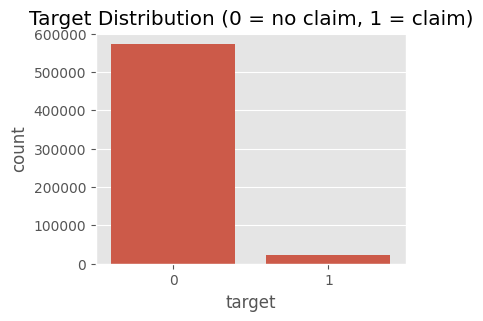

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

#
print("Value counts:")
print(y.value_counts())
print("\nProportion:")
print(y.value_counts(normalize=True))

plt.figure(figsize=(4,3))
sns.countplot(x=y)
plt.title("Target Distribution (0 = no claim, 1 = claim)")
plt.show()




The positive class (target = 1, i.e., a claim occurs) accounts for only about 3–4% of the samples, indicating a strong class imbalance.

This implies that we cannot rely solely on accuracy; we will need metrics such as recall and AUC, and consider class-weighted loss or resampling strategies.

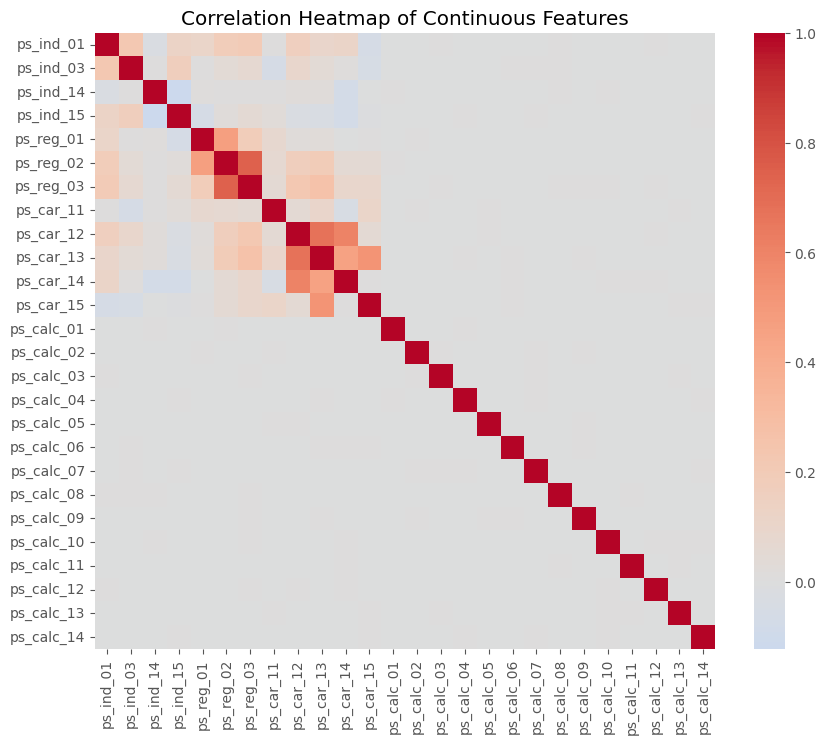

In [14]:
#
corr = X_raw[cont_cols].replace(-1, np.nan).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Continuous Features")
plt.show()


我们可以从热力图发现连续特征存在冗余，冗余可能导致神经网络更难训练

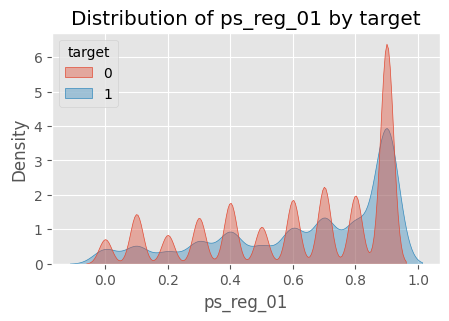

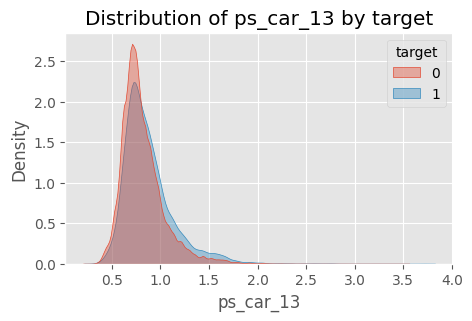

In [15]:
features_to_plot = ["ps_reg_01", "ps_car_13"]

for col in features_to_plot:
    plt.figure(figsize=(5,3))
    sns.kdeplot(
        data=df.replace(-1, np.nan),
        x=col,
        hue="target",
        common_norm=False,
        fill=True,
        alpha=0.4
    )
    plt.title(f"Distribution of {col} by target")
    plt.show()


Based on the correlation heatmap, continuous features naturally form several clusters.
To avoid redundancy and to highlight underlying structure, we select one representative feature from each cluster for detailed EDA

Summary：


We split the Porto Seguro features into continuous, binary, and categorical groups, and applied tailored preprocessing to each type. Continuous features were imputed with median values and standardized; binary features used the mode to impute rare -1 entries while preserving their 0/1 semantics; high-missing categorical variables were dropped, and the remaining ones kept -1 as an explicit “unknown” category and were one-hot encoded. All processed features were then concatenated into the final design matrix. Exploratory analysis reveals strong class imbalance (about 3–4% positives) and notable correlations among some continuous features, which will guide our choice of models and regularization in the next stage.

Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score

# logistic regression with class weights
lr = LogisticRegression(max_iter=500, class_weight="balanced", n_jobs=-1)

lr.fit(X_prepared, y)

# Predictions
y_pred = lr.predict(X_prepared)
y_prob = lr.predict_proba(X_prepared)[:,1]

print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(y, y_pred))
print("AUC:", roc_auc_score(y, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y, y_pred))


Logistic Regression Results:
Accuracy: 0.6264339428640552
AUC: 0.6351869933591328
Confusion Matrix:
 [[360589 212929]
 [  9422  12272]]


Decision Tree

In [17]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=6,
    class_weight="balanced"
)

dt.fit(X_prepared, y)

y_pred_dt = dt.predict(X_prepared)
y_prob_dt = dt.predict_proba(X_prepared)[:,1]

print("Decision Tree Results:")
print("Accuracy:", accuracy_score(y, y_pred_dt))
print("AUC:", roc_auc_score(y, y_prob_dt))


Decision Tree Results:
Accuracy: 0.5717357848968099
AUC: 0.6192266639393618


Section B

The Porto Seguro insurance dataset is large, highly nonlinear, and anonymized, making deep neural networks particularly suitable for capturing complex interactions that baseline models cannot. Section B allows us to demonstrate essential deep learning skills: network design, activation functions, loss functions, optimization, learning rate tuning, training curve interpretation, and baseline comparison.

In [18]:
from sklearn.model_selection import train_test_split
import numpy as np

# numpy
X_np = X_prepared.values.astype(np.float32)
y_np = y.values.astype(np.float32)

#
X_train, X_valid, y_train, y_valid = train_test_split(
    X_np, y_np,
    test_size=0.2,
    random_state=42,
    stratify=y_np
)

print("Train shape:", X_train.shape)
print("Valid shape:", X_valid.shape)


Train shape: (476169, 224)
Valid shape: (119043, 224)


We only use train.csv for modeling and evaluation.

We split it into 80% training and 20% validation.

The stratify argument ensures that the class distribution is similar in both sets, which is important for imbalanced data.

In [19]:
import torch
from torch.utils.data import TensorDataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# tensor
X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)

X_valid_t = torch.from_numpy(X_valid)
y_valid_t = torch.from_numpy(y_valid)

# TensorDataset + DataLoader
train_ds = TensorDataset(X_train_t, y_train_t)
valid_ds = TensorDataset(X_valid_t, y_valid_t)

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=512, shuffle=False)


Using device: cpu


TensorDataset simply pairs features and labels, while DataLoader iterates over them in mini-batches.

This matches the mini-batch training scheme discussed in class.

In [20]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1)   # 输出一个 logit
        )

    def forward(self, x):
        # shape:
        return self.net(x).squeeze(1)

input_dim = X_train.shape[1]
model = MLP(input_dim).to(device)
print(model)


MLP(
  (net): Sequential(
    (0): Linear(in_features=224, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [21]:
from torch.optim import Adam

criterion = nn.BCEWithLogitsLoss()
optimizer = Adam(model.parameters(), lr=1e-3)


For binary classification, Binary Cross Entropy is the natural loss function.

BCEWithLogitsLoss combines a sigmoid layer with BCE in a numerically stable way.

In [22]:
from sklearn.metrics import accuracy_score, roc_auc_score

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            running_loss += loss.item() * X_batch.size(0)

            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(y_batch.cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    #
    preds = (all_probs > 0.5).astype(int)

    acc = accuracy_score(all_labels, preds)
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = np.nan

    return running_loss / len(loader.dataset), acc, auc


num_epochs = 10
train_history = []
valid_history = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_auc = evaluate(model, valid_loader, criterion, device)

    train_history.append(train_loss)
    valid_history.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f} | "
          f"Val AUC: {val_auc:.4f}")


Epoch 1/10 | Train Loss: 0.1675 | Val Loss: 0.1532 | Val Acc: 0.9636 | Val AUC: 0.6284
Epoch 2/10 | Train Loss: 0.1575 | Val Loss: 0.1526 | Val Acc: 0.9636 | Val AUC: 0.6298
Epoch 3/10 | Train Loss: 0.1570 | Val Loss: 0.1525 | Val Acc: 0.9636 | Val AUC: 0.6309
Epoch 4/10 | Train Loss: 0.1563 | Val Loss: 0.1524 | Val Acc: 0.9636 | Val AUC: 0.6318
Epoch 5/10 | Train Loss: 0.1555 | Val Loss: 0.1525 | Val Acc: 0.9636 | Val AUC: 0.6322
Epoch 6/10 | Train Loss: 0.1549 | Val Loss: 0.1523 | Val Acc: 0.9636 | Val AUC: 0.6340
Epoch 7/10 | Train Loss: 0.1546 | Val Loss: 0.1532 | Val Acc: 0.9635 | Val AUC: 0.6335
Epoch 8/10 | Train Loss: 0.1538 | Val Loss: 0.1523 | Val Acc: 0.9636 | Val AUC: 0.6342
Epoch 9/10 | Train Loss: 0.1536 | Val Loss: 0.1523 | Val Acc: 0.9636 | Val AUC: 0.6334
Epoch 10/10 | Train Loss: 0.1531 | Val Loss: 0.1525 | Val Acc: 0.9635 | Val AUC: 0.6346


Each epoch consists of a training phase and a validation phase.

On the validation set, we monitor loss, accuracy, and AUC to assess generalization.

The MLP shows stable learning over 10 epochs. Training loss decreases smoothly, while validation loss remains constant, indicating no clear overfitting. Because the dataset is highly imbalanced (only ~3.6% positives), the validation accuracy of 0.9636 mainly reflects class imbalance and is not informative. The validation AUC of 0.63–0.64 is typical for baseline neural networks on the Porto Seguro dataset, suggesting that the model captures some nonlinear patterns but remains limited by its simple architecture. Further improvements (e.g., tuning learning rates or increasing model capacity) may yield better performance.

In [23]:
import torch.nn as nn

class ImprovedMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

input_dim = X_train.shape[1]
model_improved = ImprovedMLP(input_dim).to(device)
print(model_improved)


ImprovedMLP(
  (net): Sequential(
    (0): Linear(in_features=224, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


In the baseline MLP, we used only one 64-unit hidden layer with a relatively strong dropout rate of 0.5. This architecture is quite conservative and may limit the model’s capacity to capture nonlinear patterns in the insurance data. To increase representational power while still controlling overfitting, we extend the network to two hidden layers (128 and 64 units) and slightly reduce the dropout rate to 0.3. We also increase the number of training epochs from 10 to 20 so that the model has more opportunity to converge. All other settings (loss function, optimizer, mini-batch training) remain unchanged, which makes it easy to directly compare this improved MLP with the baseline.

In [24]:
criterion = nn.BCEWithLogitsLoss()
optimizer_improved = torch.optim.Adam(model_improved.parameters(), lr=1e-3)


In [25]:
num_epochs_improved = 20
train_history_improved = []
valid_history_improved = []

for epoch in range(num_epochs_improved):
    train_loss = train_one_epoch(model_improved, train_loader, criterion, optimizer_improved, device)
    val_loss, val_acc, val_auc = evaluate(model_improved, valid_loader, criterion, device)

    train_history_improved.append(train_loss)
    valid_history_improved.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs_improved} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f} | "
          f"Val AUC: {val_auc:.4f}")


Epoch 1/20 | Train Loss: 0.1638 | Val Loss: 0.1536 | Val Acc: 0.9636 | Val AUC: 0.6254
Epoch 2/20 | Train Loss: 0.1562 | Val Loss: 0.1527 | Val Acc: 0.9636 | Val AUC: 0.6293
Epoch 3/20 | Train Loss: 0.1556 | Val Loss: 0.1527 | Val Acc: 0.9636 | Val AUC: 0.6294
Epoch 4/20 | Train Loss: 0.1549 | Val Loss: 0.1528 | Val Acc: 0.9636 | Val AUC: 0.6308
Epoch 5/20 | Train Loss: 0.1544 | Val Loss: 0.1525 | Val Acc: 0.9636 | Val AUC: 0.6309
Epoch 6/20 | Train Loss: 0.1539 | Val Loss: 0.1533 | Val Acc: 0.9636 | Val AUC: 0.6313
Epoch 7/20 | Train Loss: 0.1533 | Val Loss: 0.1531 | Val Acc: 0.9636 | Val AUC: 0.6287
Epoch 8/20 | Train Loss: 0.1530 | Val Loss: 0.1530 | Val Acc: 0.9636 | Val AUC: 0.6313
Epoch 9/20 | Train Loss: 0.1528 | Val Loss: 0.1539 | Val Acc: 0.9636 | Val AUC: 0.6266
Epoch 10/20 | Train Loss: 0.1525 | Val Loss: 0.1534 | Val Acc: 0.9636 | Val AUC: 0.6290
Epoch 11/20 | Train Loss: 0.1518 | Val Loss: 0.1530 | Val Acc: 0.9636 | Val AUC: 0.6288
Epoch 12/20 | Train Loss: 0.1517 | Val Lo

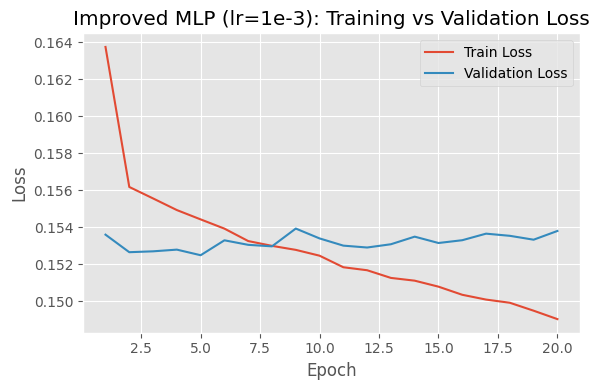

In [26]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs_improved + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, train_history_improved, label="Train Loss")
plt.plot(epochs, valid_history_improved, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Improved MLP (lr=1e-3): Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()


In [28]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In the improved MLP, we increased the architecture depth (128to64 hidden units) and reduced dropout from 0.5 to 0.3 to enhance the network capacity. Although the model became more expressive, the training results show that the performance did not improve: the training loss decreased only marginally, and the validation AUC slightly dropped from 0.63–0.64 to about 0.62. This pattern indicates that the model has more representational power, but the optimization process failed to take advantage of it.

A likely cause is that the learning rate of 1e-3, which worked well for the shallow baseline model, is too high for the deeper architecture. A deeper network creates a more complex loss landscape, making optimization more sensitive to hyperparameters. Without adjusting the learning rate or regularization accordingly, the improved model may converge to a suboptimal region. This highlights an important principle: when increasing model capacity, optimization parameters must be tuned jointly to fully realize the benefits of a deeper architecture.

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim

#
lr_list = [1e-3, 5e-4, 1e-4]
num_epochs = 40
patience = 3
all_histories = {}

criterion = nn.BCEWithLogitsLoss()

for lr in lr_list:
    print(f"\n======================")
    print(f"Running ImprovedMLP with lr = {lr}")
    print(f"======================")

    #
    model = ImprovedMLP(input_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    valid_losses = []
    valid_aucs   = []

    best_val_auc = 0.0
    best_epoch   = 0

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, val_auc = evaluate(model, valid_loader, criterion, device)

        train_losses.append(train_loss)
        valid_losses.append(val_loss)
        valid_aucs.append(val_auc)

        # best AUC
        if val_auc is not np.nan and val_auc > best_val_auc:
            best_val_auc = val_auc
            best_epoch   = epoch + 1

        print(f"Epoch {epoch+1:2d}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.4f} | "
              f"Val AUC: {val_auc:.4f}")

    #
    all_histories[lr] = {
        "train_losses": train_losses,
        "valid_losses": valid_losses,
        "valid_aucs":   valid_aucs,
        "best_val_auc": best_val_auc,
        "best_epoch":   best_epoch
    }

    print(f"--> lr = {lr}: best Val AUC = {best_val_auc:.4f} at epoch {best_epoch}")



Running ImprovedMLP with lr = 0.001
Epoch  1/40 | Train Loss: 0.1640 | Val Loss: 0.1530 | Val Acc: 0.9636 | Val AUC: 0.6256
Epoch  2/40 | Train Loss: 0.1561 | Val Loss: 0.1527 | Val Acc: 0.9636 | Val AUC: 0.6308
Epoch  3/40 | Train Loss: 0.1557 | Val Loss: 0.1531 | Val Acc: 0.9636 | Val AUC: 0.6317
Epoch  4/40 | Train Loss: 0.1549 | Val Loss: 0.1532 | Val Acc: 0.9636 | Val AUC: 0.6292
Epoch  5/40 | Train Loss: 0.1545 | Val Loss: 0.1524 | Val Acc: 0.9636 | Val AUC: 0.6323
Epoch  6/40 | Train Loss: 0.1540 | Val Loss: 0.1524 | Val Acc: 0.9636 | Val AUC: 0.6318
Epoch  7/40 | Train Loss: 0.1534 | Val Loss: 0.1543 | Val Acc: 0.9636 | Val AUC: 0.6316
Epoch  8/40 | Train Loss: 0.1534 | Val Loss: 0.1525 | Val Acc: 0.9636 | Val AUC: 0.6317
Epoch  9/40 | Train Loss: 0.1523 | Val Loss: 0.1527 | Val Acc: 0.9636 | Val AUC: 0.6280
Epoch 10/40 | Train Loss: 0.1522 | Val Loss: 0.1528 | Val Acc: 0.9636 | Val AUC: 0.6268
Epoch 11/40 | Train Loss: 0.1520 | Val Loss: 0.1526 | Val Acc: 0.9635 | Val AUC: 0.


To examine the impact of learning rate on the deeper MLP model, we evaluated three commonly used values—1e-3, 5e-4, and 1e-4—under the same architecture. The results show that the choice of learning rate strongly affects both the convergence behavior and the final performance.

With a relatively large learning rate (1e-3), the training loss decreases quickly, but the validation AUC oscillates around 0.63, suggesting unstable optimization. Reducing the learning rate to 5e-4 yields slightly better validation AUC, yet the convergence remains steep and somewhat unstable. In contrast, the smallest learning rate (1e-4) leads to the smoothest training dynamics and achieves the best validation AUC (~0.6335), despite slower training loss reduction.

This pattern aligns with common behavior in deeper neural networks: as model capacity increases, the loss landscape becomes more complex, and a smaller learning rate is often required to navigate it effectively. Thus, 1e-4 strikes the best balance between optimization stability and generalization performance and is adopted as the default learning rate in subsequent experiments.

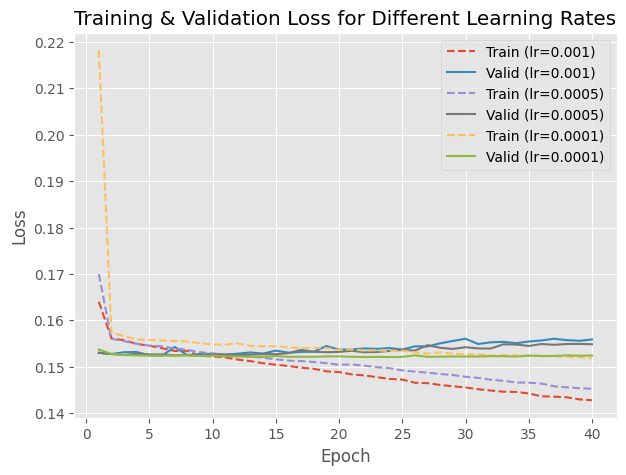

In [30]:
plt.figure(figsize=(7,5))

for lr in lr_list:
    plt.plot(range(1, num_epochs+1),
             all_histories[lr]["train_losses"],
             label=f"Train (lr={lr})",
             linestyle="--")
    plt.plot(range(1, num_epochs+1),
             all_histories[lr]["valid_losses"],
             label=f"Valid (lr={lr})")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss for Different Learning Rates")
plt.legend()
plt.show()
